# **Model Interpretation and Business Recommendations**

## Project
**Using Machine Learning to Predict Complaint Resolution Outcomes in Retail Banking: Evidence from Open Consumer Financial Complaint Data**

## Purpose of this notebook

This is the final notebook in the capstone analysis workflow.

It continues from:

- `01_data_extraction.ipynb`
- `02_exploratory_analysis.ipynb`
- `03_hypothesis_tests.ipynb`
- `04_model_training.ipynb`

The purpose is to interpret the trained models, review error patterns, examine subgroup performance, and translate the findings into practical business recommendations.

## Main outputs

This notebook creates:

- final model interpretation tables;
- error analysis tables;
- subgroup performance summaries;
- threshold analysis;
- feature interpretation summaries;
- final business recommendation tables;
- final capstone findings summary.

## Important interpretation rule

The model results should be interpreted as **associations and predictive patterns**, not causal proof. The CFPB data is public complaint data and does not represent the full customer base or market share of any company.

## Interpretation Questions

This notebook answers the following practical questions:

1. Which model performed best?
2. Which variables appear most important?
3. Where does the model make the most errors?
4. Are errors concentrated by product, issue, company, state, or submission channel?
5. What threshold should be considered if the business wants higher recall?
6. What operational recommendations follow from the analysis?
7. What limitations should be reported in the capstone paper?

In [1]:
# -------------------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# -------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------
from pathlib import Path
from datetime import datetime
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# -------------------------------------------------------------------
# Project folders and file paths
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/retail-complaint-resolution-ml")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_MODELS = PROJECT_ROOT / "outputs" / "models"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = DATA_PROCESSED / "cfpb_retail_complaints_2017_2025.csv"

MODEL_PERFORMANCE_FILE = OUTPUT_TABLES / "model_training_performance_comparison.csv"
BEST_MODEL_SUMMARY_FILE = OUTPUT_TABLES / "model_training_best_model_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Processed data file:", PROCESSED_FILE)
print("Model output folder:", OUTPUT_MODELS)
print("Processed file exists:", PROCESSED_FILE.exists())

Project root: /content/drive/MyDrive/retail-complaint-resolution-ml
Processed data file: /content/drive/MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv
Model output folder: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/models
Processed file exists: True


In [4]:
# -------------------------------------------------------------------
# Check required files
# -------------------------------------------------------------------
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Please run 01_data_extraction.ipynb first. "
        f"Expected file: {PROCESSED_FILE}"
    )

print("Processed dataset found.")
print(f"File size: {PROCESSED_FILE.stat().st_size / (1024**2):,.2f} MB")
print(f"Last modified: {datetime.fromtimestamp(PROCESSED_FILE.stat().st_mtime)}")

if not MODEL_PERFORMANCE_FILE.exists():
    print("Warning: model performance comparison file not found. Please run 04_model_training.ipynb first.")
else:
    print("Model performance file found.")

if not BEST_MODEL_SUMMARY_FILE.exists():
    print("Warning: best model summary file not found. Please run 04_model_training.ipynb first.")
else:
    print("Best model summary file found.")

Processed dataset found.
File size: 1,241.13 MB
Last modified: 2026-07-15 21:18:36
Model performance file found.
Best model summary file found.


## Step 1: Load Prior Model Results

This section loads the model performance table and best-model summary created in Notebook 04.

In [5]:
# -------------------------------------------------------------------
# Load model performance outputs
# -------------------------------------------------------------------
if MODEL_PERFORMANCE_FILE.exists():
    model_performance = pd.read_csv(MODEL_PERFORMANCE_FILE)
    print("Model performance comparison loaded.")
    display(model_performance)
else:
    model_performance = pd.DataFrame()
    print("Model performance comparison was not found.")

if BEST_MODEL_SUMMARY_FILE.exists():
    best_model_summary = pd.read_csv(BEST_MODEL_SUMMARY_FILE)
    print("Best model summary loaded.")
    display(best_model_summary)
else:
    best_model_summary = pd.DataFrame()
    print("Best model summary was not found.")

Model performance comparison loaded.


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Dummy baseline,0.9859,0.5000,0.9859,1.0000,0.9929,0.5000,0.9859
1,Structured logistic regression,0.7333,0.7908,0.9971,0.7316,0.8440,0.8506,0.9974
2,Structured + TF-IDF logistic regression,0.8112,0.7384,0.9941,0.8133,0.8947,0.8357,0.9970
3,Structured random forest,0.7884,0.8000,0.9966,0.7881,0.8802,0.8748,0.9978


Best model summary loaded.


,selection_metric,best_model,roc_auc,f1,recall,precision,average_precision
0,roc_auc,Structured random forest,0.8748,0.8802,0.7881,0.9966,0.9978


<Figure size 1200x600 with 0 Axes>

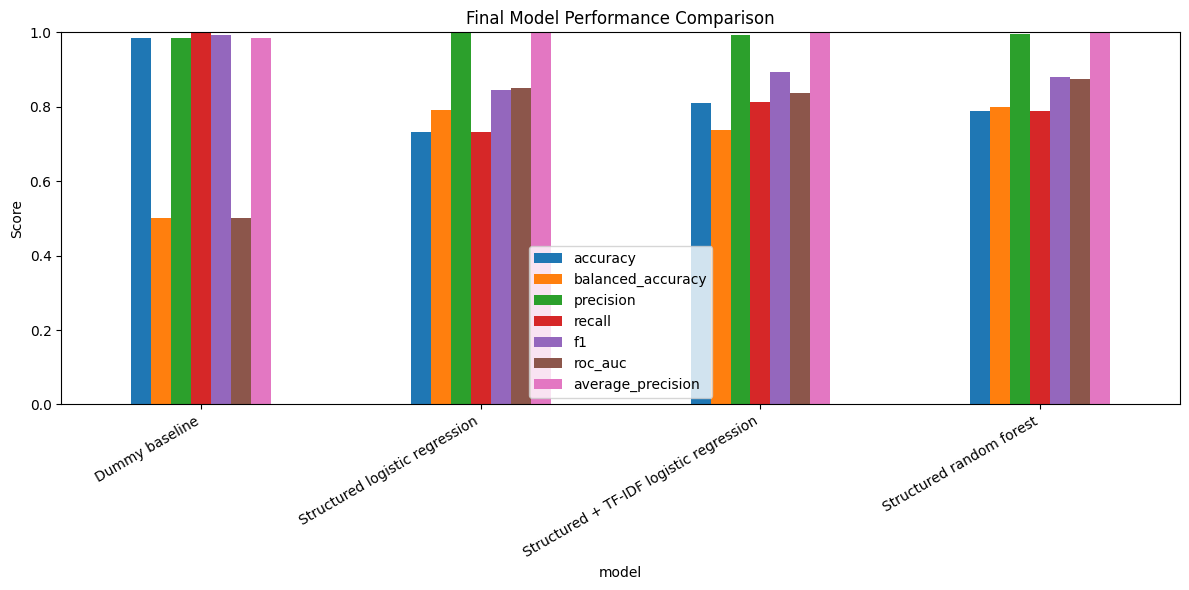

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_model_performance_comparison.png


In [6]:
# -------------------------------------------------------------------
# Visualize model performance comparison
# -------------------------------------------------------------------
if not model_performance.empty:
    metric_cols = [
        col for col in [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision"
        ]
        if col in model_performance.columns
    ]

    plot_df = model_performance.set_index("model")[metric_cols]

    plt.figure(figsize=(12, 6))
    plot_df.plot(kind="bar", figsize=(12, 6))
    plt.title("Final Model Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    figure_path = OUTPUT_FIGURES / "final_model_performance_comparison.png"
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", figure_path)
else:
    print("No model performance table available to plot.")

## Step 2: Load the Processed Dataset

The processed dataset is loaded again so that model errors and subgroup performance can be interpreted in business terms.

In [7]:
# -------------------------------------------------------------------
# Load processed dataset
# -------------------------------------------------------------------
df = pd.read_csv(PROCESSED_FILE, low_memory=False)

print("Dataset loaded.")
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", f"{df.shape[1]:,}")

df.head()

Dataset loaded.
Rows: 1,289,027
Columns: 25


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,date_received_raw,date_sent_to_company_raw,year_received,month_received,quarter_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days
0,2025-07-05 08:45:32+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed an initial disclosure for a XXXX mort...,Company believes the complaint is the result o...,"Your Favorite Lenders, Inc",OH,441XX,NaN,Web,2026-05-05 13:43:00+00:00,Closed with explanation,Yes,21636268,2025-07-05T08:45:32.000Z,2026-05-05T13:43:00.000Z,2025,2025-07,2025Q3,1,1,516,304.0
1,2025-07-11 03:39:40+00:00,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am filing a complaint against Integra Credit...,NaN,"Deinde Online Services, LLC",FL,33068,NaN,Web,2026-04-21 17:42:21+00:00,Closed with explanation,Yes,21447929,2025-07-11T03:39:40.000Z,2026-04-21T17:42:21.000Z,2025,2025-07,2025Q3,1,1,998,284.0
2,2025-08-11 18:59:48+00:00,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"Del Toro Loan Servicing, Inc",CA,94552,Older American,Phone,2025-08-15 06:00:26+00:00,Closed with explanation,No,15198684,2025-08-11T18:59:48.000Z,2025-08-15T06:00:26.000Z,2025,2025-08,2025Q3,0,0,0,3.0
3,2025-08-17 01:15:29+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...",Company disputes the facts presented in the co...,"RESCO, INC.",HI,96815,NaN,Web,2026-05-04 13:13:09+00:00,Closed with explanation,Yes,21848458,2025-08-17T01:15:29.000Z,2026-05-04T13:13:09.000Z,2025,2025-08,2025Q3,1,1,1805,260.0
4,2025-09-25 15:49:13+00:00,Mortgage,VA mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,NaN,NaN,"Mortgage Express, Inc.",GA,30662,Servicemember,Web,2026-04-30 15:44:57+00:00,Closed with explanation,Yes,21669790,2025-09-25T15:49:13.000Z,2026-04-30T15:44:57.000Z,2025,2025-09,2025Q3,1,0,0,216.0


In [8]:
# -------------------------------------------------------------------
# Basic preparation
# -------------------------------------------------------------------
for col in ["date_received", "date_sent_to_company"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

if "year_received" not in df.columns and "date_received" in df.columns:
    df["year_received"] = df["date_received"].dt.year

if "month_received" not in df.columns and "date_received" in df.columns:
    df["month_received"] = df["date_received"].dt.to_period("M").astype(str)

if "timely_response_binary" not in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

if "has_narrative" not in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

if "narrative_length" not in df.columns:
    df["narrative_length"] = df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

df["narrative_text"] = df["consumer_complaint_narrative"].fillna("").astype(str)

print("Preparation complete.")
print("Valid target records:", f"{df['timely_response_binary'].notna().sum():,}")

Preparation complete.
Valid target records: 1,289,027


## Step 3: Recreate the Modeling Sample

Notebook 04 used a controlled stratified sample for practical runtime. This notebook recreates the same sample settings so that saved models can be interpreted on the same test split.

In [9]:
# -------------------------------------------------------------------
# Modeling configuration
# -------------------------------------------------------------------
RANDOM_STATE = 42
MODEL_SAMPLE_SIZE = 150_000
TOP_N_COMPANIES = 50
TOP_N_STATES = 50

print("Random state:", RANDOM_STATE)
print("Model sample size:", MODEL_SAMPLE_SIZE)

Random state: 42
Model sample size: 150000


In [10]:
# -------------------------------------------------------------------
# Recreate modeling dataset
# -------------------------------------------------------------------
model_df = df.dropna(subset=["timely_response_binary"]).copy()

# Group high-cardinality company and state fields
if "company" in model_df.columns:
    top_companies = model_df["company"].value_counts().head(TOP_N_COMPANIES).index
    model_df["company_grouped"] = np.where(model_df["company"].isin(top_companies), model_df["company"], "Other")
else:
    model_df["company_grouped"] = "Unknown"

if "state" in model_df.columns:
    top_states = model_df["state"].value_counts().head(TOP_N_STATES).index
    model_df["state_grouped"] = np.where(model_df["state"].isin(top_states), model_df["state"], "Other")
else:
    model_df["state_grouped"] = "Unknown"

categorical_features = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "tags",
    "year_received"
]

numeric_features = [
    "has_narrative",
    "narrative_length"
]

text_feature = "narrative_text"

categorical_features = [col for col in categorical_features if col in model_df.columns]
numeric_features = [col for col in numeric_features if col in model_df.columns]

required_model_cols = ["timely_response_binary"] + categorical_features + numeric_features + [text_feature]
model_df = model_df[required_model_cols].copy()

for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown").astype(str)

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0)

model_df[text_feature] = model_df[text_feature].fillna("").astype(str)
model_df["timely_response_binary"] = model_df["timely_response_binary"].astype(int)

# Same stratified sample setting as Notebook 04
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df, _ = train_test_split(
        model_df,
        train_size=MODEL_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=model_df["timely_response_binary"]
    )

print("Modeling dataset shape:", model_df.shape)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Text feature:", text_feature)

model_df.head()

Modeling dataset shape: (150000, 13)
Categorical features: ['product', 'sub_product', 'issue', 'sub_issue', 'submitted_via', 'state_grouped', 'company_grouped', 'tags', 'year_received']
Numeric features: ['has_narrative', 'narrative_length']
Text feature: narrative_text


,timely_response_binary,product,sub_product,issue,sub_issue,submitted_via,state_grouped,company_grouped,tags,year_received,has_narrative,narrative_length,narrative_text
1062841,1,Credit card or prepaid card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,Phone,FL,"BANK OF AMERICA, NATIONAL ASSOCIATION",Unknown,2021,0,0,
830479,1,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Unknown,Web,IN,Mr. Cooper Group Inc.,Unknown,2019,0,0,
1240541,1,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Web,NY,CAPITAL ONE FINANCIAL CORPORATION,Unknown,2022,0,0,
171344,1,Mortgage,FHA mortgage,Trouble during payment process,Paying off the loan,Web,TN,PNC Bank N.A.,Unknown,2024,0,0,
585155,1,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Confusing or missing disclosures,Unknown,Web,OH,Chime Financial Inc,Unknown,2025,1,987,Chime bank drafted a total of XXXX dollars fro...


In [11]:
# -------------------------------------------------------------------
# Train-test split
# -------------------------------------------------------------------
X = model_df[categorical_features + numeric_features + [text_feature]].copy()
y = model_df["timely_response_binary"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

structured_features = categorical_features + numeric_features

X_test_structured = X_test[structured_features].copy()
X_test_text = X_test[categorical_features + numeric_features + [text_feature]].copy()

print("Test rows:", f"{len(X_test):,}")
display(y_test.value_counts(normalize=True).reset_index())

Test rows: 45,000


,timely_response_binary,proportion
0,1,0.985933
1,0,0.014067


## Step 4: Load Trained Models

The notebook loads the models saved by Notebook 04. If a model file is missing, run Notebook 04 first.

In [12]:
# -------------------------------------------------------------------
# Load saved models
# -------------------------------------------------------------------
model_files = {
    "Dummy baseline": OUTPUT_MODELS / "model_baseline_dummy.pkl",
    "Structured logistic regression": OUTPUT_MODELS / "model_structured_logistic.pkl",
    "Structured + TF-IDF logistic regression": OUTPUT_MODELS / "model_structured_text_logistic.pkl",
    "Structured random forest": OUTPUT_MODELS / "model_structured_random_forest.pkl"
}

loaded_models = {}

for model_name, model_path in model_files.items():
    if model_path.exists():
        loaded_models[model_name] = joblib.load(model_path)
        print(f"Loaded: {model_name}")
    else:
        print(f"Missing model file: {model_name} -> {model_path}")

print("Models loaded:", list(loaded_models.keys()))

Loaded: Dummy baseline
Loaded: Structured logistic regression
Loaded: Structured + TF-IDF logistic regression
Loaded: Structured random forest
Models loaded: ['Dummy baseline', 'Structured logistic regression', 'Structured + TF-IDF logistic regression', 'Structured random forest']


## Step 5: Select the Best Available Model

The best model is selected using the previous ROC-AUC ranking if available. If the prior summary is unavailable, the notebook uses the structured + TF-IDF model if it exists.

In [13]:
# -------------------------------------------------------------------
# Select best model
# -------------------------------------------------------------------
best_model_name = None

if not best_model_summary.empty and "best_model" in best_model_summary.columns:
    candidate = best_model_summary.loc[0, "best_model"]
    if candidate in loaded_models:
        best_model_name = candidate

if best_model_name is None:
    preferred_order = [
        "Structured + TF-IDF logistic regression",
        "Structured logistic regression",
        "Structured random forest",
        "Dummy baseline"
    ]

    for name in preferred_order:
        if name in loaded_models:
            best_model_name = name
            break

if best_model_name is None:
    raise FileNotFoundError(
        "No trained model files were found. Please run 04_model_training.ipynb first."
    )

best_model = loaded_models[best_model_name]

print("Selected best available model:", best_model_name)

Selected best available model: Structured random forest


In [14]:
# -------------------------------------------------------------------
# Prepare correct test matrix for selected model
# -------------------------------------------------------------------
def get_test_matrix_for_model(model_name):
    if model_name in ["Structured logistic regression", "Structured random forest"]:
        return X_test_structured
    elif model_name == "Structured + TF-IDF logistic regression":
        return X_test_text
    else:
        return X_test

X_test_best = get_test_matrix_for_model(best_model_name)

print("Best model test matrix shape:", X_test_best.shape)

Best model test matrix shape: (45000, 11)


## Step 6: Best Model Evaluation

This section evaluates the selected model on the test set and saves the results.

In [15]:
# -------------------------------------------------------------------
# Evaluate selected best model
# -------------------------------------------------------------------
y_pred = best_model.predict(X_test_best)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_best)[:, 1]
else:
    y_score = y_pred

best_metrics = pd.DataFrame([{
    "model": best_model_name,
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score),
    "average_precision": average_precision_score(y_test, y_score)
}])

for col in best_metrics.columns:
    if col != "model":
        best_metrics[col] = best_metrics[col].round(4)

best_metrics_path = OUTPUT_TABLES / "final_best_model_evaluation.csv"
best_metrics.to_csv(best_metrics_path, index=False)

print("Saved table:", best_metrics_path)
best_metrics

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_evaluation.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Structured random forest,0.7884,0.8,0.9966,0.7881,0.8802,0.8748,0.9978


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_confusion_matrix.csv


,Predicted 0: Not timely,Predicted 1: Timely
Actual 0: Not timely,514,119
Actual 1: Timely,9403,34964


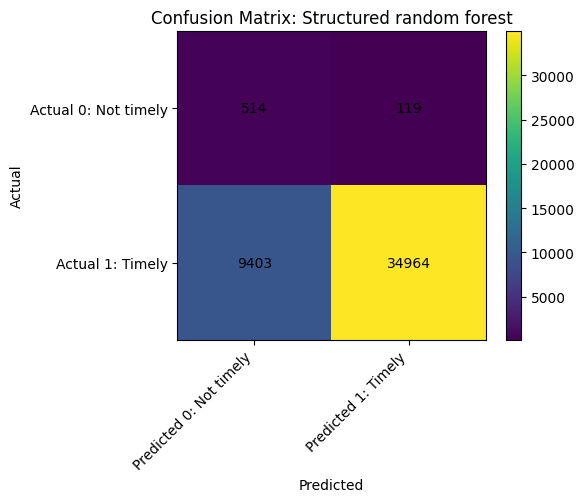

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_best_model_confusion_matrix.png


In [16]:
# -------------------------------------------------------------------
# Confusion matrix for best model
# -------------------------------------------------------------------
best_cm = confusion_matrix(y_test, y_pred)

best_cm_df = pd.DataFrame(
    best_cm,
    index=["Actual 0: Not timely", "Actual 1: Timely"],
    columns=["Predicted 0: Not timely", "Predicted 1: Timely"]
)

best_cm_path = OUTPUT_TABLES / "final_best_model_confusion_matrix.csv"
best_cm_df.reset_index().rename(columns={"index": "actual"}).to_csv(best_cm_path, index=False)

print("Saved table:", best_cm_path)
display(best_cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(best_cm_df.values, interpolation="nearest")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.colorbar()
tick_marks = np.arange(len(best_cm_df.columns))
plt.xticks(tick_marks, best_cm_df.columns, rotation=45, ha="right")
plt.yticks(tick_marks, best_cm_df.index)

for i in range(best_cm_df.shape[0]):
    for j in range(best_cm_df.shape[1]):
        plt.text(j, i, best_cm_df.values[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_best_model_confusion_matrix.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## Step 7: ROC and Precision-Recall Curves

ROC-AUC is useful for overall ranking ability. Precision-recall curves are especially useful when the target class is imbalanced.

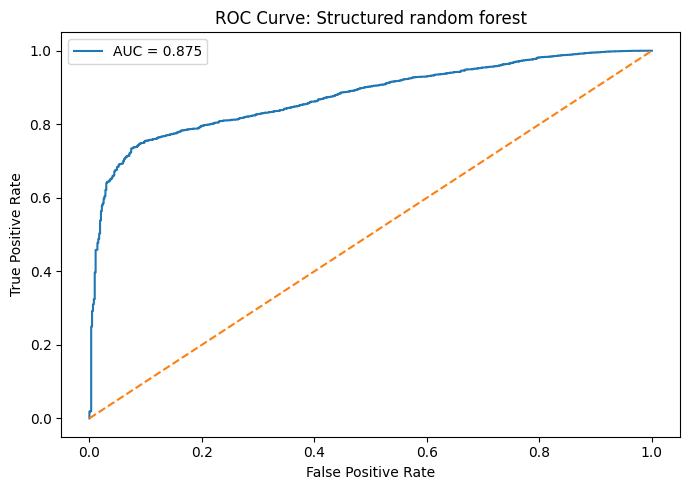

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_roc_curve_points.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_best_model_roc_curve.png


In [17]:
# -------------------------------------------------------------------
# ROC curve
# -------------------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
roc_auc_value = roc_auc_score(y_test, y_score)

roc_curve_df = pd.DataFrame({
    "false_positive_rate": fpr,
    "true_positive_rate": tpr,
    "threshold": roc_thresholds
})

roc_curve_path = OUTPUT_TABLES / "final_best_model_roc_curve_points.csv"
roc_curve_df.to_csv(roc_curve_path, index=False)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve: {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_best_model_roc_curve.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved table:", roc_curve_path)
print("Saved figure:", figure_path)

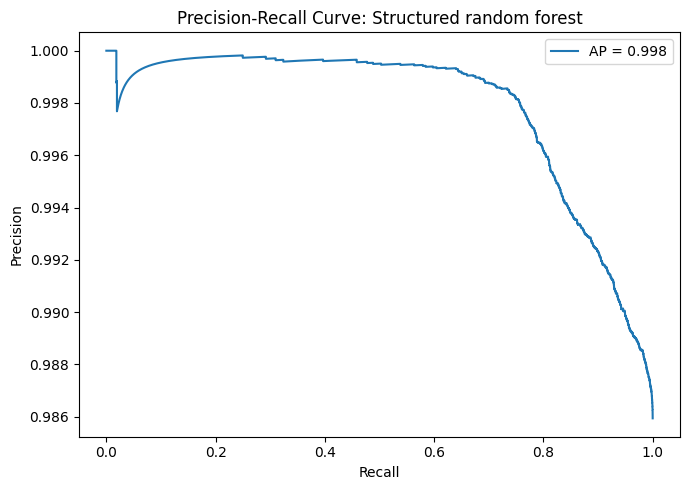

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_best_model_precision_recall_curve_points.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_best_model_precision_recall_curve.png


In [18]:
# -------------------------------------------------------------------
# Precision-recall curve
# -------------------------------------------------------------------
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test, y_score)
average_precision_value = average_precision_score(y_test, y_score)

pr_curve_df = pd.DataFrame({
    "precision": precision_values,
    "recall": recall_values,
    "threshold": list(pr_thresholds) + [np.nan]
})

pr_curve_path = OUTPUT_TABLES / "final_best_model_precision_recall_curve_points.csv"
pr_curve_df.to_csv(pr_curve_path, index=False)

plt.figure(figsize=(7, 5))
plt.plot(recall_values, precision_values, label=f"AP = {average_precision_value:.3f}")
plt.title(f"Precision-Recall Curve: {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_best_model_precision_recall_curve.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved table:", pr_curve_path)
print("Saved figure:", figure_path)

## Step 8: Threshold Analysis

The default classification threshold is 0.50. In complaint operations, a bank may choose a lower or higher threshold depending on the goal.

For example:

- If the goal is to catch more at-risk complaints, increase recall.
- If the goal is to avoid too many false alerts, increase precision.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_threshold_analysis.csv


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.10,0.9861,0.5071,0.9861,1.0000,0.9930
1,0.15,0.9856,0.5263,0.9867,0.9989,0.9928
2,0.20,0.9816,0.5538,0.9874,0.9939,0.9907
3,0.25,0.9599,0.6059,0.9890,0.9701,0.9795
4,0.30,0.9364,0.6423,0.9901,0.9449,0.9670
5,0.35,0.9044,0.6915,0.9918,0.9106,0.9494
6,0.40,0.8492,0.7374,0.9937,0.8524,0.9177
7,0.45,0.8185,0.7709,0.9952,0.8199,0.8991
8,0.50,0.7884,0.8000,0.9966,0.7881,0.8802
9,0.55,0.7609,0.8227,0.9979,0.7591,0.8622


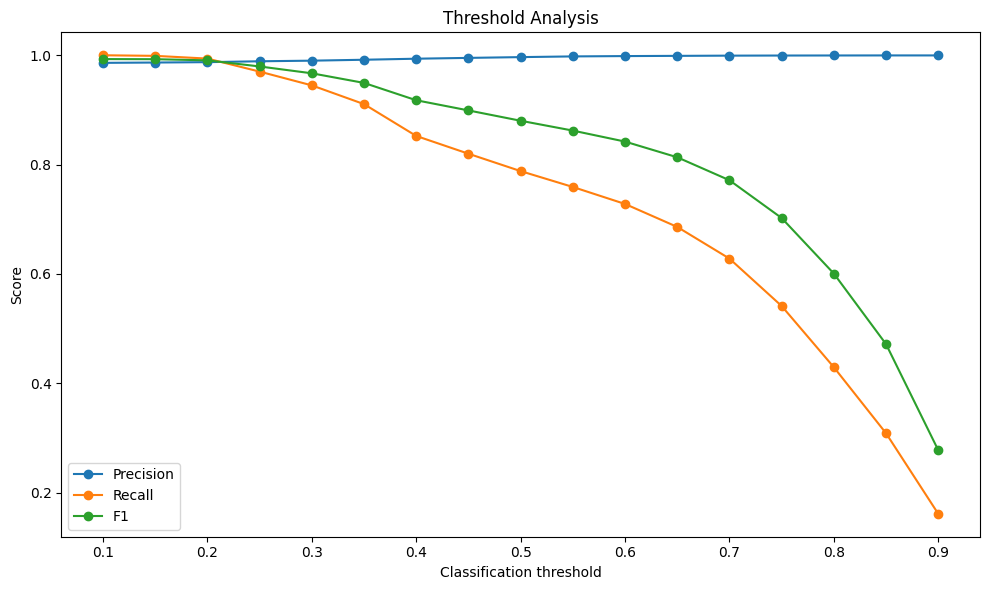

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/final_threshold_analysis.png


In [19]:
# -------------------------------------------------------------------
# Threshold analysis
# -------------------------------------------------------------------
thresholds_to_test = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in thresholds_to_test:
    threshold_pred = (y_score >= threshold).astype(int)

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, threshold_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, threshold_pred),
        "precision": precision_score(y_test, threshold_pred, zero_division=0),
        "recall": recall_score(y_test, threshold_pred, zero_division=0),
        "f1": f1_score(y_test, threshold_pred, zero_division=0)
    })

threshold_analysis = pd.DataFrame(threshold_rows)

for col in ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]:
    threshold_analysis[col] = threshold_analysis[col].round(4)

threshold_path = OUTPUT_TABLES / "final_threshold_analysis.csv"
threshold_analysis.to_csv(threshold_path, index=False)

print("Saved table:", threshold_path)
display(threshold_analysis)

plt.figure(figsize=(10, 6))
plt.plot(threshold_analysis["threshold"], threshold_analysis["precision"], marker="o", label="Precision")
plt.plot(threshold_analysis["threshold"], threshold_analysis["recall"], marker="o", label="Recall")
plt.plot(threshold_analysis["threshold"], threshold_analysis["f1"], marker="o", label="F1")
plt.title("Threshold Analysis")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

figure_path = OUTPUT_FIGURES / "final_threshold_analysis.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## Step 9: Error Analysis

This section labels each test record as:

- True Positive
- True Negative
- False Positive
- False Negative

This helps identify where the model performs well and where it struggles.

In [20]:
# -------------------------------------------------------------------
# Create error analysis dataframe
# -------------------------------------------------------------------
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred
error_df["predicted_probability_timely"] = y_score

def classify_error(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "True Positive"
    elif row["actual"] == 0 and row["predicted"] == 0:
        return "True Negative"
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "False Positive"
    elif row["actual"] == 1 and row["predicted"] == 0:
        return "False Negative"
    else:
        return "Unknown"

error_df["prediction_result"] = error_df.apply(classify_error, axis=1)

error_summary = error_df["prediction_result"].value_counts().reset_index()
error_summary.columns = ["prediction_result", "count"]
error_summary["percent"] = (error_summary["count"] / error_summary["count"].sum() * 100).round(2)

error_summary_path = OUTPUT_TABLES / "final_error_summary.csv"
error_summary.to_csv(error_summary_path, index=False)

print("Saved table:", error_summary_path)
error_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_summary.csv


,prediction_result,count,percent
0,True Positive,34964,77.70
1,False Negative,9403,20.90
2,True Negative,514,1.14
3,False Positive,119,0.26


In [21]:
# -------------------------------------------------------------------
# Error rate by category helper
# -------------------------------------------------------------------
def error_rate_by_group(dataframe, group_col, min_records=100):
    if group_col not in dataframe.columns:
        return pd.DataFrame()

    grouped = (
        dataframe
        .groupby(group_col, dropna=False)
        .agg(
            total_records=("actual", "size"),
            false_positive_count=("prediction_result", lambda x: (x == "False Positive").sum()),
            false_negative_count=("prediction_result", lambda x: (x == "False Negative").sum()),
            error_count=("prediction_result", lambda x: x.isin(["False Positive", "False Negative"]).sum()),
            average_predicted_probability=("predicted_probability_timely", "mean"),
            actual_timely_rate=("actual", "mean"),
            predicted_timely_rate=("predicted", "mean")
        )
        .reset_index()
    )

    grouped["error_rate_percent"] = (grouped["error_count"] / grouped["total_records"] * 100).round(2)
    grouped["false_positive_rate_percent"] = (grouped["false_positive_count"] / grouped["total_records"] * 100).round(2)
    grouped["false_negative_rate_percent"] = (grouped["false_negative_count"] / grouped["total_records"] * 100).round(2)
    grouped["actual_timely_rate_percent"] = (grouped["actual_timely_rate"] * 100).round(2)
    grouped["predicted_timely_rate_percent"] = (grouped["predicted_timely_rate"] * 100).round(2)
    grouped["average_predicted_probability"] = grouped["average_predicted_probability"].round(4)

    grouped = grouped[grouped["total_records"] >= min_records].copy()
    grouped = grouped.sort_values("error_rate_percent", ascending=False)

    return grouped

In [22]:
# -------------------------------------------------------------------
# Error analysis by main categories
# -------------------------------------------------------------------
error_group_columns = [
    "product",
    "issue",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "year_received",
    "tags"
]

error_tables = {}

for group_col in error_group_columns:
    if group_col in error_df.columns:
        table = error_rate_by_group(error_df, group_col, min_records=100)
        error_tables[group_col] = table

        output_path = OUTPUT_TABLES / f"final_error_analysis_by_{group_col}.csv"
        table.to_csv(output_path, index=False)

        print("\n", "=" * 80)
        print(f"Error analysis by {group_col}")
        print("Saved table:", output_path)
        display(table.head(20))


Error analysis by product
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_product.csv


,product,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
10,"Payday loan, title loan, personal loan, or adv...",858,0,662,662,0.3498,0.966200,0.194639,77.16,0.00,77.16,96.62,19.46
9,"Payday loan, title loan, or personal loan",1071,0,790,790,0.3253,0.948646,0.211018,73.76,0.00,73.76,94.86,21.10
0,Bank account or service,252,0,174,174,0.4071,0.952381,0.261905,69.05,0.00,69.05,95.24,26.19
2,Consumer Loan,136,0,78,78,0.4225,0.970588,0.397059,57.35,0.00,57.35,97.06,39.71
12,Vehicle loan or lease,2874,4,1337,1341,0.5660,0.981211,0.517397,46.66,0.14,46.52,98.12,51.74
11,Prepaid card,566,2,213,215,0.4625,0.931095,0.558304,37.99,0.35,37.63,93.11,55.83
7,Mortgage,7731,11,2826,2837,0.6176,0.985772,0.621653,36.70,0.14,36.55,98.58,62.17
5,"Money transfer, virtual currency, or money ser...",5787,18,1003,1021,0.6877,0.984275,0.814066,17.64,0.31,17.33,98.43,81.41
1,Checking or savings account,11664,53,1372,1425,0.7228,0.990226,0.877143,12.22,0.45,11.76,99.02,87.71
4,Credit card or prepaid card,7198,16,742,758,0.7703,0.987219,0.886357,10.53,0.22,10.31,98.72,88.64



Error analysis by issue
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_issue.csv


,issue,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
20,Charged fees or interest you didn't expect,448,0,343,343,0.3170,0.953125,0.187500,76.56,0.00,76.56,95.31,18.75
92,Problem with the payoff process at the end of ...,170,0,128,128,0.3242,0.958824,0.205882,75.29,0.00,75.29,95.88,20.59
43,Getting the loan,160,0,112,112,0.3887,0.975000,0.275000,70.00,0.00,70.00,97.50,27.50
1,"Account opening, closing, or management",132,0,88,88,0.3964,0.931818,0.265152,66.67,0.00,66.67,93.18,26.52
105,Struggling to pay your loan,582,0,364,364,0.4448,0.955326,0.329897,62.54,0.00,62.54,95.53,32.99
41,Getting a line of credit,103,0,62,62,0.4198,0.990291,0.388350,60.19,0.00,60.19,99.03,38.83
22,Closing on a mortgage,571,2,285,287,0.5149,0.971979,0.476357,50.26,0.35,49.91,97.20,47.64
54,"Loan servicing, payments, escrow account",179,0,87,87,0.5713,0.994413,0.508380,48.60,0.00,48.60,99.44,50.84
98,Repossession,344,0,167,167,0.5861,0.991279,0.505814,48.55,0.00,48.55,99.13,50.58
60,Managing the loan or lease,977,0,470,470,0.5490,0.982600,0.501535,48.11,0.00,48.11,98.26,50.15



Error analysis by submitted_via
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_submitted_via.csv


...

,company_grouped,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
32,Other,9670,27,8205,8232,0.3649,0.954395,0.108687,85.13,0.28,84.85,95.44,10.87
2,"BANK OF AMERICA, NATIONAL ASSOCIATION",2987,23,705,728,0.5935,0.976565,0.748242,24.37,0.77,23.60,97.66,74.82
30,Netspend Corporation,157,3,20,23,0.6163,0.968153,0.859873,14.65,1.91,12.74,96.82,85.99
5,"Block, Inc.",1999,18,253,271,0.7254,0.982991,0.865433,13.56,0.90,12.66,98.30,86.54
25,KEYCORP,184,0,10,10,0.7042,1.000000,0.945652,5.43,0.00,5.43,100.00,94.57
49,WELLS FARGO & COMPANY,2964,19,140,159,0.6789,0.981781,0.940958,5.36,0.64,4.72,98.18,94.10
35,REGIONS FINANCIAL CORPORATION,193,0,9,9,0.6994,1.000000,0.953368,4.66,0.00,4.66,100.00,95.34
46,TRUIST FINANCIAL CORPORATION,543,8,5,13,0.6833,0.985267,0.990792,2.39,1.47,0.92,98.53,99.08
10,"CITIZENS FINANCIAL GROUP, INC.",354,0,7,7,0.7530,1.000000,0.980226,1.98,0.00,1.98,100.00,98.02
23,"HUNTINGTON NATIONAL BANK, THE",164,1,2,3,0.7173,0.993902,0.987805,1.83,0.61,1.22,99.39,98.78



Error analysis by year_received
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_year_received.csv


,year_received,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
0,2017,3076,1,982,983,0.6092,0.980819,0.661899,31.96,0.03,31.92,98.08,66.19
4,2021,3891,7,1072,1079,0.6469,0.978412,0.704703,27.73,0.18,27.55,97.84,70.47
5,2022,4482,14,1152,1166,0.6564,0.988621,0.734717,26.02,0.31,25.70,98.86,73.47
2,2019,2917,13,690,703,0.6730,0.985259,0.753171,24.10,0.45,23.65,98.53,75.32
1,2018,2993,9,702,711,0.6723,0.985299,0.753759,23.76,0.30,23.45,98.53,75.38
3,2020,3677,10,784,794,0.6649,0.978787,0.768289,21.59,0.27,21.32,97.88,76.83
6,2023,5700,16,1121,1137,0.7060,0.987719,0.793860,19.95,0.28,19.67,98.77,79.39
8,2025,11366,33,1817,1850,0.7466,0.988914,0.831955,16.28,0.29,15.99,98.89,83.20
7,2024,6898,16,1083,1099,0.7437,0.988692,0.834010,15.93,0.23,15.70,98.87,83.40



Error analysis by tags
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_error_analysis_by_tags.csv


,tags,total_records,false_positive_count,false_negative_count,error_count,average_predicted_probability,actual_timely_rate,predicted_timely_rate,error_rate_percent,false_positive_rate_percent,false_negative_rate_percent,actual_timely_rate_percent,predicted_timely_rate_percent
2,Servicemember,3649,11,886,897,0.6714,0.984105,0.744314,24.58,0.30,24.28,98.41,74.43
3,Unknown,37309,91,7755,7846,0.7001,0.985848,0.780428,21.03,0.24,20.79,98.58,78.04
0,Older American,3159,14,596,610,0.6975,0.987971,0.803735,19.31,0.44,18.87,98.80,80.37
1,"Older American, Servicemember",883,3,166,169,0.7006,0.989807,0.805210,19.14,0.34,18.80,98.98,80.52


## Step 10: Subgroup Performance Review

This section evaluates whether model performance varies across important subgroups. It is useful for fairness, governance, and operational review.

The subgroup review does not prove bias, but it highlights where more review may be needed.

In [23]:
# -------------------------------------------------------------------
# Subgroup performance helper
# -------------------------------------------------------------------
def subgroup_performance(dataframe, group_col, min_records=100):
    if group_col not in dataframe.columns:
        return pd.DataFrame()

    rows = []

    for group_value, group_data in dataframe.groupby(group_col, dropna=False):
        if len(group_data) < min_records:
            continue

        y_true_group = group_data["actual"]
        y_pred_group = group_data["predicted"]

        rows.append({
            group_col: group_value,
            "total_records": len(group_data),
            "actual_timely_rate_percent": round(y_true_group.mean() * 100, 2),
            "predicted_timely_rate_percent": round(y_pred_group.mean() * 100, 2),
            "accuracy": round(accuracy_score(y_true_group, y_pred_group), 4),
            "balanced_accuracy": round(balanced_accuracy_score(y_true_group, y_pred_group), 4),
            "precision": round(precision_score(y_true_group, y_pred_group, zero_division=0), 4),
            "recall": round(recall_score(y_true_group, y_pred_group, zero_division=0), 4),
            "f1": round(f1_score(y_true_group, y_pred_group, zero_division=0), 4)
        })

    result = pd.DataFrame(rows)

    if len(result) > 0:
        result = result.sort_values("balanced_accuracy", ascending=True)

    return result

In [24]:
# -------------------------------------------------------------------
# Subgroup performance tables
# -------------------------------------------------------------------
subgroup_columns = [
    "product",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "year_received"
]

subgroup_tables = {}

for group_col in subgroup_columns:
    if group_col in error_df.columns:
        table = subgroup_performance(error_df, group_col, min_records=100)
        subgroup_tables[group_col] = table

        output_path = OUTPUT_TABLES / f"final_subgroup_performance_by_{group_col}.csv"
        table.to_csv(output_path, index=False)

        print("\n", "=" * 80)
        print(f"Subgroup performance by {group_col}")
        print("Saved table:", output_path)
        display(table.head(20))


Subgroup performance by product
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_product.csv


,product,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
8,"Payday loan, title loan, personal loan, or adv...",858,96.62,19.46,0.2284,0.6007,1.0000,0.2014,0.3353
7,"Payday loan, title loan, or personal loan",1071,94.86,21.10,0.2624,0.6112,1.0000,0.2224,0.3639
0,Bank account or service,252,95.24,26.19,0.3095,0.6375,1.0000,0.2750,0.4314
2,Consumer Loan,136,97.06,39.71,0.4265,0.7045,1.0000,0.4091,0.5806
1,Checking or savings account,11664,99.02,87.71,0.8778,0.7081,0.9948,0.8812,0.9346
10,Vehicle loan or lease,2874,98.12,51.74,0.5334,0.7259,0.9973,0.5259,0.6886
3,Credit card,6828,99.56,97.09,0.9709,0.7365,0.9977,0.9729,0.9852
6,Mortgage,7731,98.58,62.17,0.6330,0.7646,0.9977,0.6292,0.7717
9,Prepaid card,566,93.11,55.83,0.6201,0.7723,0.9937,0.5958,0.7450
5,"Money transfer, virtual currency, or money ser...",5787,98.43,81.41,0.8236,0.8131,0.9962,0.8239,0.9019



Subgroup performance by submitted_via
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_submitted_via.csv


,submitted_via,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
3,Referral,4013,98.68,78.97,0.7974,0.7950,0.9965,0.7975,0.8860
4,Web,36946,98.60,78.07,0.7892,0.7959,0.9965,0.7890,0.8807
2,Postal mail,749,99.20,76.64,0.7717,0.8023,0.9983,0.7712,0.8702
1,Phone,3181,98.27,75.76,0.7718,0.8392,0.9979,0.7694,0.8689
0,Fax,111,98.20,76.58,0.7838,0.8899,1.0000,0.7798,0.8763



Subgroup performance by state_grouped
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_state_grouped.csv


,state_grouped,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
44,WV,149,99.33,72.48,0.7181,0.3615,0.9907,0.7230,0.8359
6,DC,237,99.58,84.81,0.8439,0.4237,0.9950,0.8475,0.9153
21,MN,453,99.34,78.59,0.7837,0.5600,0.9944,0.7867,0.8784
29,NV,624,98.56,77.08,0.7724,0.6656,0.9917,0.7756,0.8704
14,IN,556,98.38,78.42,0.7860,0.6727,0.9908,0.7898,0.8789
23,MS,286,98.60,69.58,0.7028,0.7261,0.9950,0.7021,0.8233
41,VA,1375,98.55,75.20,0.7578,0.7293,0.9942,0.7587,0.8606
19,MD,1241,98.71,78.73,0.7921,0.7405,0.9949,0.7935,0.8828
17,LA,532,98.68,76.13,0.7669,0.7410,0.9951,0.7676,0.8667
39,TX,4025,98.81,79.55,0.8000,0.7444,0.9953,0.8014,0.8879



Subgroup performance by company_grouped
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_company_grouped.csv


,company_grouped,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
23,"HUNTINGTON NATIONAL BANK, THE",164,99.39,98.78,0.9817,0.4939,0.9938,0.9877,0.9908
46,TRUIST FINANCIAL CORPORATION,543,98.53,99.08,0.9761,0.4953,0.9851,0.9907,0.9879
39,"SOFI TECHNOLOGIES, INC.",151,99.34,99.34,0.9868,0.4967,0.9933,0.9933,0.9933
21,GOLDMAN SACHS BANK USA,416,99.76,99.52,0.9928,0.4976,0.9976,0.9952,0.9964
13,"Coinbase, Inc.",356,99.44,99.72,0.9916,0.4986,0.9944,0.9972,0.9958
17,"Early Warning Services, LLC",905,99.89,100.00,0.9989,0.5000,0.9989,1.0000,0.9994
26,"LoanCare, LLC",227,99.12,100.00,0.9912,0.5000,0.9912,1.0000,0.9956
1,AMERICAN EXPRESS COMPANY,1084,99.82,100.00,0.9982,0.5000,0.9982,1.0000,0.9991
28,Mr. Cooper Group Inc.,454,99.56,100.00,0.9956,0.5000,0.9956,1.0000,0.9978
42,"Shellpoint Partners, LLC",450,99.33,100.00,0.9933,0.5000,0.9933,1.0000,0.9967



Subgroup performance by year_received
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_subgroup_performance_by_year_received.csv


,year_received,total_records,actual_timely_rate_percent,predicted_timely_rate_percent,accuracy,balanced_accuracy,precision,recall,f1
2,2019,2917,98.53,75.32,0.7590,0.7288,0.9941,0.7599,0.8614
5,2022,4482,98.86,73.47,0.7398,0.7328,0.9957,0.7400,0.8490
1,2018,2993,98.53,75.38,0.7624,0.7787,0.9960,0.7620,0.8634
6,2023,5700,98.77,79.39,0.8005,0.7862,0.9965,0.8009,0.8880
8,2025,11366,98.89,83.20,0.8372,0.7882,0.9965,0.8383,0.9106
4,2021,3891,97.84,70.47,0.7227,0.8175,0.9974,0.7184,0.8352
7,2024,6898,98.87,83.40,0.8407,0.8180,0.9972,0.8412,0.9126
3,2020,3677,97.88,76.83,0.7841,0.8270,0.9965,0.7822,0.8764
0,2017,3076,98.08,66.19,0.6804,0.8288,0.9995,0.6745,0.8055


## Step 11: Feature Interpretation

This section loads coefficient and feature-importance tables created in Notebook 04.

For logistic regression:

- positive coefficients indicate features associated with higher probability of timely response;
- negative coefficients indicate features associated with lower probability of timely response.

For random forest:

- importance values indicate which features were useful for tree splits;
- they do not show direction of impact.

In [25]:
# -------------------------------------------------------------------
# Load feature interpretation tables
# -------------------------------------------------------------------
feature_files = {
    "Structured logistic coefficients": OUTPUT_TABLES / "model_structured_logistic_coefficients.csv",
    "Structured + TF-IDF logistic coefficients": OUTPUT_TABLES / "model_structured_text_logistic_coefficients.csv",
    "Random forest feature importance": OUTPUT_TABLES / "model_structured_random_forest_feature_importance.csv"
}

feature_tables = {}

for label, path in feature_files.items():
    if path.exists():
        feature_tables[label] = pd.read_csv(path)
        print(f"Loaded: {label}")
    else:
        print(f"Missing: {label} -> {path}")

print("Loaded feature tables:", list(feature_tables.keys()))

Loaded: Structured logistic coefficients
Loaded: Structured + TF-IDF logistic coefficients
Loaded: Random forest feature importance
Loaded feature tables: ['Structured logistic coefficients', 'Structured + TF-IDF logistic coefficients', 'Random forest feature importance']


In [26]:
# -------------------------------------------------------------------
# Top positive and negative coefficients
# -------------------------------------------------------------------
for label, table in feature_tables.items():
    print("\n", "=" * 100)
    print(label)

    if "coefficient" in table.columns:
        positive = table.sort_values("coefficient", ascending=False).head(30)
        negative = table.sort_values("coefficient", ascending=True).head(30)

        positive_path = OUTPUT_TABLES / f"final_top_positive_features_{label.lower().replace(' ', '_').replace('+', 'plus').replace('-', '_')}.csv"
        negative_path = OUTPUT_TABLES / f"final_top_negative_features_{label.lower().replace(' ', '_').replace('+', 'plus').replace('-', '_')}.csv"

        positive.to_csv(positive_path, index=False)
        negative.to_csv(negative_path, index=False)

        print("Top positive features")
        display(positive)

        print("Top negative features")
        display(negative)

    elif "importance" in table.columns:
        top_importance = table.sort_values("importance", ascending=False).head(30)

        importance_path = OUTPUT_TABLES / f"final_top_feature_importance_{label.lower().replace(' ', '_')}.csv"
        top_importance.to_csv(importance_path, index=False)

        print("Top feature importance")
        display(top_importance)


Structured logistic coefficients
Top positive features


,feature,coefficient,absolute_coefficient
2,cat__sub_issue_You never received your bill or...,3.859460,3.859460
9,cat__sub_product_Conventional adjustable mortg...,3.123114,3.123114
10,cat__sub_product_Manufactured home loan,3.114827,3.114827
11,cat__sub_issue_Problem with paying off the loan,3.018931,3.018931
12,cat__sub_issue_Problem using the card to withd...,3.001193,3.001193
13,cat__company_grouped_U.S. BANCORP,2.882532,2.882532
14,cat__state_grouped_SD,2.859468,2.859468
15,cat__sub_issue_Changes in terms mid-deal or af...,2.858604,2.858604
16,cat__sub_product_Home equity loan or line of c...,2.771374,2.771374
17,cat__issue_Credit monitoring or identity theft...,2.685512,2.685512


Top negative features


,feature,coefficient,absolute_coefficient
0,cat__company_grouped_Other,-4.591129,4.591129
1,"cat__company_grouped_BANK OF AMERICA, NATIONAL...",-3.868397,3.868397
3,"cat__company_grouped_Shellpoint Partners, LLC",-3.724020,3.724020
4,cat__company_grouped_Netspend Corporation,-3.667572,3.667572
5,cat__company_grouped_TRUIST FINANCIAL CORPORATION,-3.414774,3.414774
6,"cat__company_grouped_Block, Inc.",-3.386160,3.386160
7,cat__company_grouped_WELLS FARGO & COMPANY,-3.370834,3.370834
8,"cat__company_grouped_LoanCare, LLC",-3.339669,3.339669
23,cat__sub_issue_Late or other fees,-2.587303,2.587303
24,"cat__sub_issue_Excess mileage, damage, or wear...",-2.577584,2.577584



Structured + TF-IDF logistic coefficients
Top positive features


,feature,coefficient,absolute_coefficient
6,text__provide,4.350903,4.350903
10,text__principal,4.098066,4.098066
16,text__person,3.784646,3.784646
19,cat__sub_issue_You never received your bill or...,3.734058,3.734058
25,text__atm,3.675547,3.675547
42,text__suntrust,3.317739,3.317739
46,text__flagstar,3.232493,3.232493
47,text__told xxxx,3.211729,3.211729
50,text__didnt,3.185688,3.185688
51,text__attached,3.181304,3.181304


Top negative features


,feature,coefficient,absolute_coefficient
0,text__codes,-4.832375,4.832375
1,text__better,-4.716601,4.716601
2,cat__company_grouped_Other,-4.494481,4.494481
3,text__years ago,-4.491853,4.491853
4,text__forged,-4.369356,4.369356
5,text__billing,-4.367036,4.367036
7,text__disbursement,-4.326325,4.326325
8,text__california,-4.109073,4.109073
9,text__coverage,-4.098655,4.098655
11,text__xxxx today,-3.956235,3.956235



Random forest feature importance
Top feature importance


,feature,importance
0,cat__company_grouped_Other,0.277721
1,"cat__company_grouped_BANK OF AMERICA, NATIONAL...",0.044469
2,cat__company_grouped_JPMORGAN CHASE & CO.,0.040352
3,cat__sub_product_General-purpose credit card o...,0.029113
4,cat__company_grouped_CAPITAL ONE FINANCIAL COR...,0.026219
5,cat__product_Credit card,0.025999
6,cat__company_grouped_WELLS FARGO & COMPANY,0.023733
7,cat__sub_issue_Unknown,0.022910
8,"cat__company_grouped_CITIBANK, N.A.",0.020700
9,num__narrative_length,0.016963


## Step 12: Business Interpretation Tables

This section converts the technical results into business-friendly findings and recommendations.

In [27]:
# -------------------------------------------------------------------
# Create final business findings table
# -------------------------------------------------------------------
business_findings = []

if not model_performance.empty:
    best_row = model_performance.sort_values("roc_auc", ascending=False).iloc[0]
    business_findings.append({
        "finding_area": "Best predictive model",
        "technical_finding": f"The best model by ROC-AUC was {best_row['model']} with ROC-AUC of {best_row['roc_auc']}.",
        "business_meaning": "Complaint metadata and narrative signals can be used to rank complaints by response-risk level.",
        "recommended_action": "Use the model as an early-warning support tool, not as an automated decision-maker."
    })

if "product" in error_tables and len(error_tables["product"]) > 0:
    top_error_product = error_tables["product"].iloc[0]["product"]
    business_findings.append({
        "finding_area": "Product-level error concentration",
        "technical_finding": f"The highest model error rate among product groups appears in: {top_error_product}.",
        "business_meaning": "Some product groups may have more complex complaint patterns or less predictable response behavior.",
        "recommended_action": "Review product-level complaint workflows and escalation rules for high-error product groups."
    })

if "issue" in error_tables and len(error_tables["issue"]) > 0:
    top_error_issue = error_tables["issue"].iloc[0]["issue"]
    business_findings.append({
        "finding_area": "Issue-level error concentration",
        "technical_finding": f"The highest model error rate among issue groups appears in: {top_error_issue}.",
        "business_meaning": "Certain complaint issues may require deeper operational review.",
        "recommended_action": "Use issue-level monitoring to improve routing, triage, and response playbooks."
    })

if "company_grouped" in subgroup_tables and len(subgroup_tables["company_grouped"]) > 0:
    business_findings.append({
        "finding_area": "Company-level variation",
        "technical_finding": "Model performance and response patterns vary across company groups.",
        "business_meaning": "Company-specific operations, complaint volume, and process maturity may influence response outcomes.",
        "recommended_action": "Interpret company-level findings carefully and avoid ranking companies without market-share context."
    })

if "state_grouped" in subgroup_tables and len(subgroup_tables["state_grouped"]) > 0:
    business_findings.append({
        "finding_area": "Geographic variation",
        "technical_finding": "Model performance and response rates vary across state groups.",
        "business_meaning": "Geographic differences may reflect complaint mix, regulation, customer behavior, or operational patterns.",
        "recommended_action": "Use geographic findings for operational monitoring, not for unfair treatment of customers."
    })

business_findings.append({
    "finding_area": "Model governance",
    "technical_finding": "The model is trained on observational public complaint data.",
    "business_meaning": "The model may reflect historical patterns and data limitations.",
    "recommended_action": "Use human review, monitoring, documentation, and periodic retraining before any operational deployment."
})

business_findings_df = pd.DataFrame(business_findings)

business_findings_path = OUTPUT_TABLES / "final_business_findings_and_recommendations.csv"
business_findings_df.to_csv(business_findings_path, index=False)

print("Saved table:", business_findings_path)
business_findings_df

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_business_findings_and_recommendations.csv


,finding_area,technical_finding,business_meaning,recommended_action
0,Best predictive model,The best model by ROC-AUC was Structured rando...,Complaint metadata and narrative signals can b...,Use the model as an early-warning support tool...
1,Product-level error concentration,The highest model error rate among product gro...,Some product groups may have more complex comp...,Review product-level complaint workflows and e...
2,Issue-level error concentration,The highest model error rate among issue group...,Certain complaint issues may require deeper op...,"Use issue-level monitoring to improve routing,..."
3,Company-level variation,Model performance and response patterns vary a...,"Company-specific operations, complaint volume,...",Interpret company-level findings carefully and...
4,Geographic variation,Model performance and response rates vary acro...,Geographic differences may reflect complaint m...,Use geographic findings for operational monito...
5,Model governance,The model is trained on observational public c...,The model may reflect historical patterns and ...,"Use human review, monitoring, documentation, a..."


In [28]:
# -------------------------------------------------------------------
# Create implementation roadmap
# -------------------------------------------------------------------
implementation_roadmap = pd.DataFrame([
    {
        "phase": "Phase 1",
        "focus": "Analytical validation",
        "activities": "Validate model results, review feature interpretation, check subgroup performance, confirm business relevance.",
        "owner": "Analytics team with complaint operations",
        "risk_control": "Document assumptions, limitations, and leakage exclusions."
    },
    {
        "phase": "Phase 2",
        "focus": "Pilot dashboard",
        "activities": "Create a complaint-risk dashboard showing predicted risk, product, issue, company group, and state-level monitoring.",
        "owner": "Operations analytics and complaint management",
        "risk_control": "Use predictions as decision support only, with human review."
    },
    {
        "phase": "Phase 3",
        "focus": "Workflow integration",
        "activities": "Route high-risk complaints for earlier review, escalation, or specialist handling.",
        "owner": "Complaint operations and technology",
        "risk_control": "Monitor false positives and false negatives before scaling."
    },
    {
        "phase": "Phase 4",
        "focus": "Governance and monitoring",
        "activities": "Monitor drift, subgroup performance, complaints by product and issue, and model performance over time.",
        "owner": "Model governance, risk, compliance, and business owners",
        "risk_control": "Set retraining schedule and approval process."
    }
])

roadmap_path = OUTPUT_TABLES / "final_implementation_roadmap.csv"
implementation_roadmap.to_csv(roadmap_path, index=False)

print("Saved table:", roadmap_path)
implementation_roadmap

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_implementation_roadmap.csv


,phase,focus,activities,owner,risk_control
0,Phase 1,Analytical validation,"Validate model results, review feature interpr...",Analytics team with complaint operations,"Document assumptions, limitations, and leakage..."
1,Phase 2,Pilot dashboard,Create a complaint-risk dashboard showing pred...,Operations analytics and complaint management,"Use predictions as decision support only, with..."
2,Phase 3,Workflow integration,"Route high-risk complaints for earlier review,...",Complaint operations and technology,Monitor false positives and false negatives be...
3,Phase 4,Governance and monitoring,"Monitor drift, subgroup performance, complaint...","Model governance, risk, compliance, and busine...",Set retraining schedule and approval process.


## Step 13: Limitations for the Final Report

These limitations should be included in the capstone paper.

In [29]:
# -------------------------------------------------------------------
# Final limitations table
# -------------------------------------------------------------------
limitations = pd.DataFrame([
    {
        "limitation": "Public complaint data is not the full customer population.",
        "meaning": "The dataset contains complaints submitted to the CFPB, not all customers or all complaints received directly by companies.",
        "mitigation": "Avoid using results as market-share or company-quality rankings."
    },
    {
        "limitation": "Observational data does not prove causation.",
        "meaning": "The models identify associations and predictive patterns, not causal effects.",
        "mitigation": "Use language such as associated with, predictive of, or correlated with."
    },
    {
        "limitation": "Class imbalance may affect model behavior.",
        "meaning": "If timely responses dominate the dataset, accuracy can be misleading.",
        "mitigation": "Use recall, F1, ROC-AUC, average precision, and balanced accuracy."
    },
    {
        "limitation": "Narrative availability depends on consumer consent.",
        "meaning": "Not every complaint has a narrative, so text analysis is based on a subset of records.",
        "mitigation": "Use has_narrative and narrative_length carefully, and report narrative coverage."
    },
    {
        "limitation": "Company and state fields need careful interpretation.",
        "meaning": "Complaint volume may be influenced by customer base, geography, product mix, and reporting behavior.",
        "mitigation": "Do not interpret raw complaint counts as performance rankings."
    },
    {
        "limitation": "Possible data leakage must be controlled.",
        "meaning": "Fields created after company response should not be used for intake-stage prediction.",
        "mitigation": "Exclude company_response_to_consumer and company_public_response from timely-response prediction."
    }
])

limitations_path = OUTPUT_TABLES / "final_capstone_limitations.csv"
limitations.to_csv(limitations_path, index=False)

print("Saved table:", limitations_path)
limitations

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_capstone_limitations.csv


,limitation,meaning,mitigation
0,Public complaint data is not the full customer...,The dataset contains complaints submitted to t...,Avoid using results as market-share or company...
1,Observational data does not prove causation.,The models identify associations and predictiv...,"Use language such as associated with, predicti..."
2,Class imbalance may affect model behavior.,"If timely responses dominate the dataset, accu...","Use recall, F1, ROC-AUC, average precision, an..."
3,Narrative availability depends on consumer con...,"Not every complaint has a narrative, so text a...",Use has_narrative and narrative_length careful...
4,Company and state fields need careful interpre...,Complaint volume may be influenced by customer...,Do not interpret raw complaint counts as perfo...
5,Possible data leakage must be controlled.,Fields created after company response should n...,Exclude company_response_to_consumer and compa...


## Step 14: Final Capstone Summary

This section creates a concise final summary that can be used in the capstone report.

In [30]:
# -------------------------------------------------------------------
# Final capstone summary
# -------------------------------------------------------------------
final_summary_rows = []

final_summary_rows.append({
    "section": "Objective",
    "summary": "The project used CFPB consumer complaint data to examine and predict complaint resolution outcomes in retail banking."
})

final_summary_rows.append({
    "section": "Data",
    "summary": f"The processed dataset contained {df.shape[0]:,} records and {df.shape[1]:,} columns after filtering for relevant products and the 2017-2025 period."
})

if not best_metrics.empty:
    final_summary_rows.append({
        "section": "Best model",
        "summary": f"The selected model was {best_model_name}, with ROC-AUC {best_metrics.loc[0, 'roc_auc']} and F1 {best_metrics.loc[0, 'f1']} on the test set."
    })

final_summary_rows.append({
    "section": "Interpretation",
    "summary": "The model results suggest that product type, issue category, company group, state group, submission channel, and narrative features can help identify response-risk patterns."
})

final_summary_rows.append({
    "section": "Business value",
    "summary": "The analysis can support complaint triage, early-warning dashboards, product-level monitoring, issue-level operational review, and governance reporting."
})

final_summary_rows.append({
    "section": "Governance",
    "summary": "The model should be used as decision support with human oversight, not as a fully automated decision system."
})

final_summary = pd.DataFrame(final_summary_rows)

summary_path = OUTPUT_TABLES / "final_capstone_summary.csv"
final_summary.to_csv(summary_path, index=False)

print("Saved table:", summary_path)
final_summary

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/final_capstone_summary.csv


,section,summary
0,Objective,The project used CFPB consumer complaint data ...
1,Data,"The processed dataset contained 1,289,027 reco..."
2,Best model,The selected model was Structured random fores...
3,Interpretation,"The model results suggest that product type, i..."
4,Business value,"The analysis can support complaint triage, ear..."
5,Governance,The model should be used as decision support w...


## Step 15: Final Output Checklist

This confirms the main final outputs were created.

In [31]:
# -------------------------------------------------------------------
# Final output checklist
# -------------------------------------------------------------------
expected_outputs = [
    OUTPUT_TABLES / "final_best_model_evaluation.csv",
    OUTPUT_TABLES / "final_best_model_confusion_matrix.csv",
    OUTPUT_TABLES / "final_threshold_analysis.csv",
    OUTPUT_TABLES / "final_error_summary.csv",
    OUTPUT_TABLES / "final_business_findings_and_recommendations.csv",
    OUTPUT_TABLES / "final_implementation_roadmap.csv",
    OUTPUT_TABLES / "final_capstone_limitations.csv",
    OUTPUT_TABLES / "final_capstone_summary.csv",
    OUTPUT_FIGURES / "final_model_performance_comparison.png",
    OUTPUT_FIGURES / "final_best_model_confusion_matrix.png",
    OUTPUT_FIGURES / "final_best_model_roc_curve.png",
    OUTPUT_FIGURES / "final_best_model_precision_recall_curve.png",
    OUTPUT_FIGURES / "final_threshold_analysis.png"
]

checklist = pd.DataFrame([
    {
        "file": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024**2), 4) if path.exists() else None
    }
    for path in expected_outputs
])

checklist

,file,exists,size_mb
0,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
1,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
2,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0007
3,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
4,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0017
5,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0009
6,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0013
7,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0008
8,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0874
9,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0551


# Completion Note

This completes the notebook workflow.

The five-notebook structure is:

1. `01_data_extraction.ipynb`
2. `02_exploratory_analysis.ipynb`
3. `03_hypothesis_tests.ipynb`
4. `04_model_training.ipynb`
5. `05_model_interpretation.ipynb`

The next task is to convert the notebook outputs into the final capstone report, including methodology, findings, limitations, recommendations, and appendices.